In [1]:
# Cell 1: Setup
import caspy
import numpy as np
from IPython.display import Audio
import matplotlib.pyplot as plt

print(f"✓ CASPy version: {caspy.__version__}")

✓ CASPy version: 0.1.0


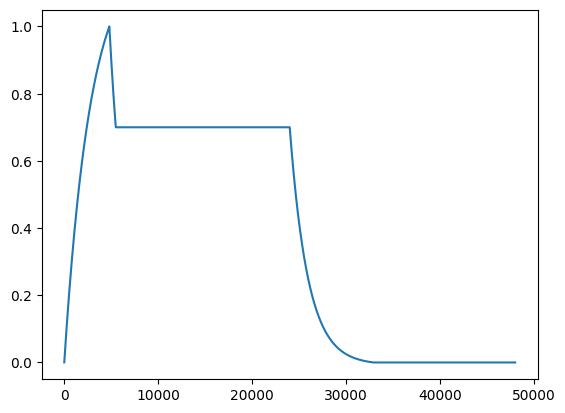

In [52]:
# Cell 2: Test all oscillators
sample_rate = 48000
duration = 1  # 100ms
num_samples = np.float32(sample_rate * duration)

env = caspy.adsr.ADSR()
env.set_sample_rate(sample_rate)
env.set_attack_time(0.1)
env.set_decay_time(0.2)
env.set_sustain_level(0.7)
env.set_release_time(0.2)

env.note_on()
buf1 = env.render_algorithm(num_samples * 0.5)  # 1 second
env.note_off()
buf2 = env.render_algorithm(num_samples * 0.5)
env_buffer = np.append(buf1, buf2)
plt.plot(env_buffer)
plt.show()

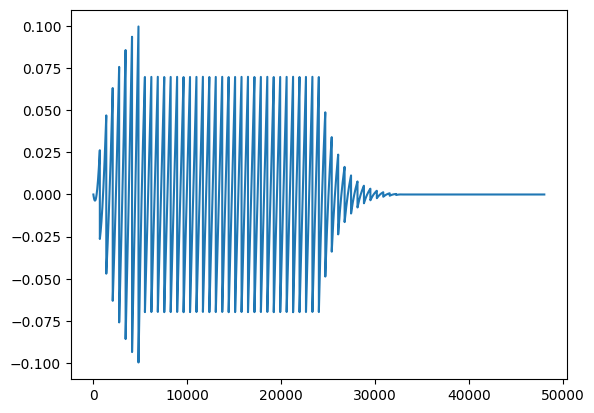

In [55]:
import sounddevice as sd
volume = 0.1 # BE CAREFUL MAKING THIS LOUDER
# Create a short beep
osc = caspy.Saw()
osc.set_frequency(70.0, sample_rate)
saw_buffer = volume * osc.render(sample_rate)
saw_with_env_buffer = env_buffer * saw_buffer

plt.plot(saw_with_env_buffer)
plt.show()

Audio(saw_with_env_buffer, rate=sample_rate)


NameError: name 'sample_rate' is not defined